## 1. Chargement des données

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuration
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Chargement du dataset propre
try:
    df = pd.read_csv('public/dataset_technova_clean.csv')
    print(f"Données chargées : {df.shape}")
except FileNotFoundError:
    print("Erreur : Le fichier 'dataset_technova_clean.csv' est introuvable. Veuillez exécuter le Notebook 1.")

Données chargées : (1470, 32)


## 2. Nettoyage Final (Feature Selection)

In [13]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'id_employee', 'eval_number', 'code_sondage', # Identifiants
]

# Suppression
df_ml = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Dimensions après suppression du bruit : {df_ml.shape}")

Dimensions après suppression du bruit : (1470, 30)


## 3. Analyse des Corrélations (Pearson)

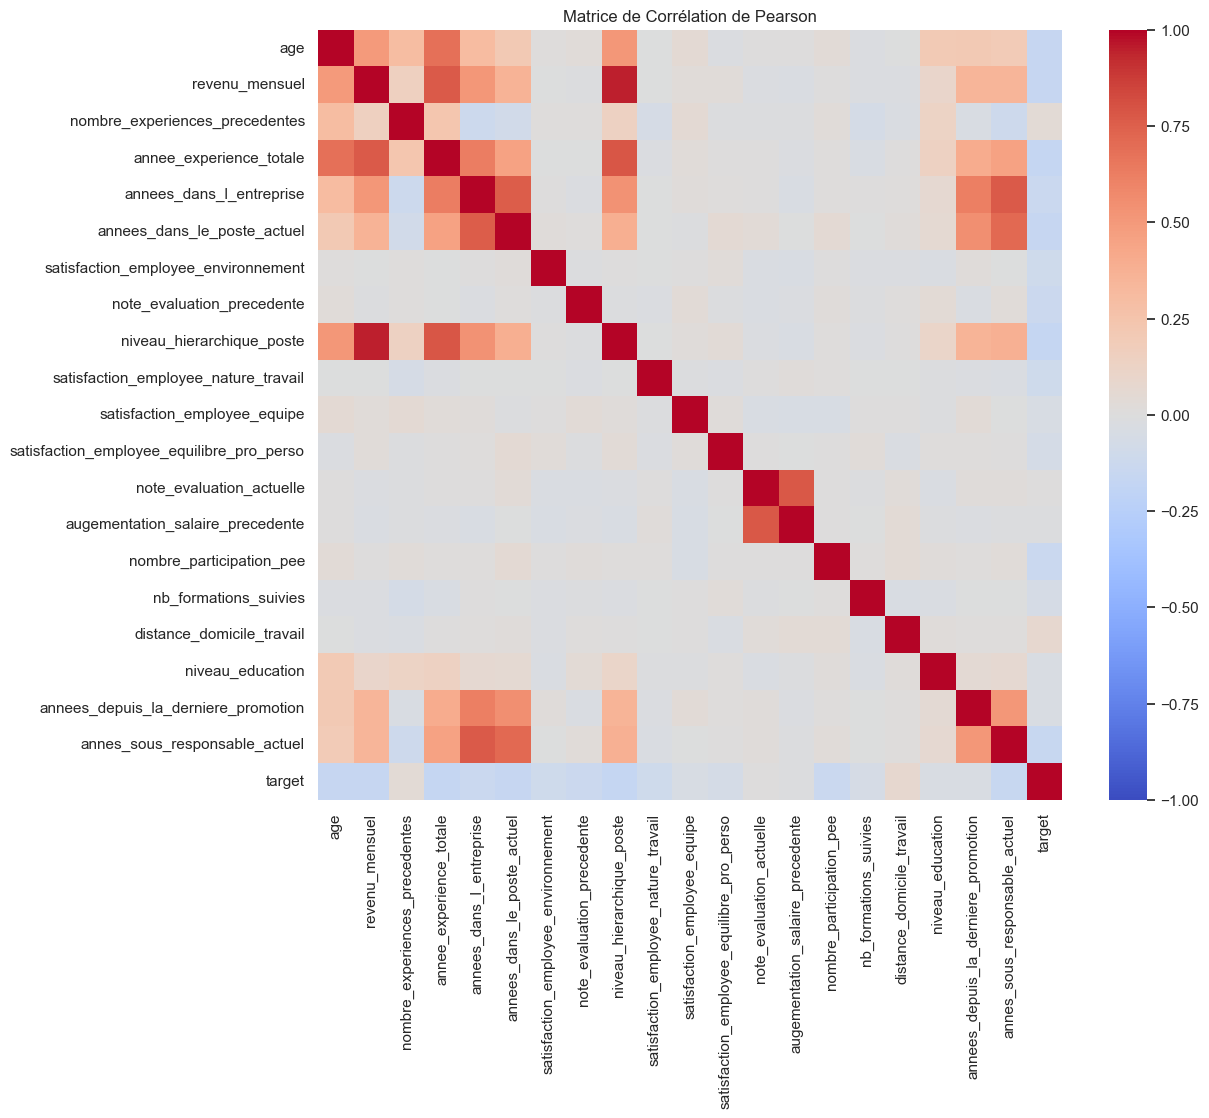

Alertes colinéarité (> 0.9) :
- niveau_hierarchique_poste <--> revenu_mensuel : 0.95


In [14]:
# Calcul de la matrice de corrélation (sur variables numériques uniquement)
numeric_cols = df_ml.select_dtypes(include=[np.number]).columns
corr_matrix = df_ml[numeric_cols].corr()

# Affichage de la Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matrice de Corrélation de Pearson")
plt.show()

# Détection automatique des paires très corrélées (> 0.9)
print("Alertes colinéarité (> 0.9) :")
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            print(f"- {corr_matrix.columns[i]} <--> {corr_matrix.columns[j]} : {corr_matrix.iloc[i, j]:.2f}")

### 3.1 Supprimer les colonnes en corrélation

In [15]:
## Supprimer la colonne niveau_hierarchique_poste
df_ml = df_ml.drop(columns=['niveau_hierarchique_poste'], errors='ignore')

## 4. Analyse visuelle avancée (Pairplot)

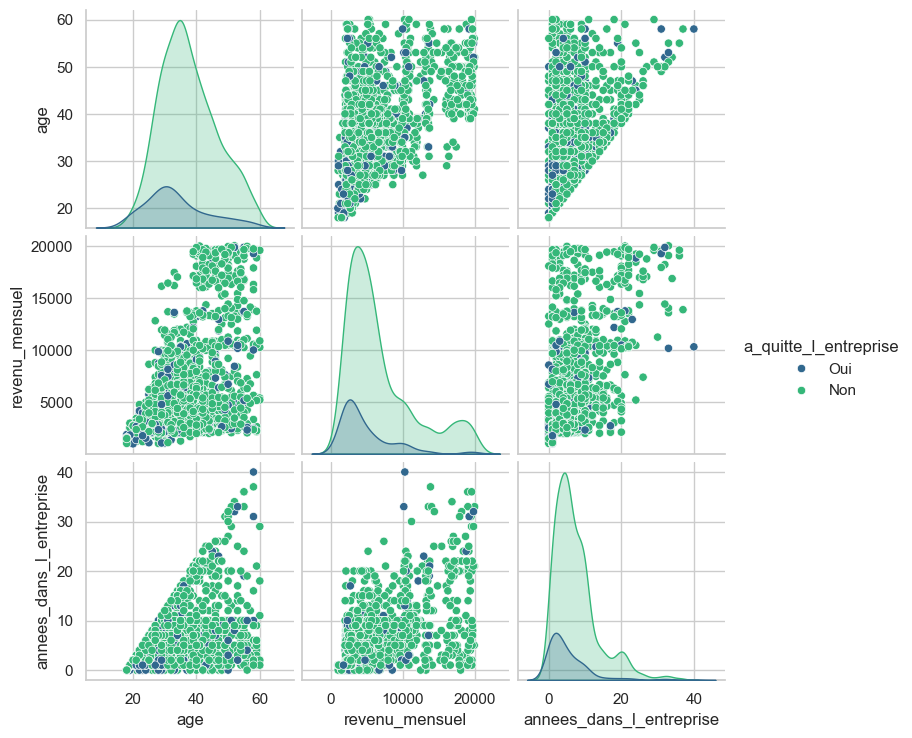

In [16]:
# Sélection de variables clés pour garder le graphique lisible
selected_features = ['age', 'revenu_mensuel', 'annees_dans_l_entreprise', 'a_quitte_l_entreprise']

sns.pairplot(df_ml[selected_features], hue='a_quitte_l_entreprise', palette='viridis')
plt.show()

## 5. Encodage des Variables (Encoding)

### Stratégie d'encodage :
1. **Target (Cible)** : `a_quitte_l_entreprise` ➔ 0 ou 1.
2. **Variables Binaires** : `genre`, `heure_supplementaires`, etc. ➔ 0 ou 1.
3. **Variables Ordinales** : `frequence_deplacement` ➔ 0, 1, 2 (car il y a une hiérarchie : Non < Rare < Fréquent).
4. **Variables Nominales** : `departement`, `poste`, etc. ➔ **One-Hot Encoding** (création d'une colonne par catégorie).

In [ ]:


# 2. Variables Binaires (Mapping manuel)
binary_map = {'Oui': 1, 'Non': 0, 'Y': 1, 'N': 0, 'M': 0, 'F': 1}
cols_binary = ['heure_supplementaires', 'ayant_enfants', 'genre']

for col in cols_binary:
    if df_ml[col].dtype == 'object':
        df_ml[col] = df_ml[col].map(binary_map)

# 3. Variable Ordinale (Hiérarchie)
travel_map = {'Non': 0, 'Rare': 1, 'Occasionnel': 1, 'Frequent': 2}
df_ml['frequence_deplacement'] = df_ml['frequence_deplacement'].map(travel_map).fillna(0)

# 4. Variables Nominales (One-Hot Encoding)
# On utilise drop_first=True pour éviter la multicolinéarité parfaite (Dummy Trap)
cols_nominal = ['departement', 'poste', 'domaine_etude', 'statut_marital']
df_ml = pd.get_dummies(df_ml, columns=cols_nominal, drop_first=True, dtype=int)

print("Encodage terminé.")
print(f"Dataset final : {df_ml.shape} (Toutes les colonnes sont numériques)")
df_ml.head()

Encodage terminé.
Dataset final : (1470, 41) (Toutes les colonnes sont numériques)


,age,genre,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,target,departement_Consulting,departement_Ressources Humaines,poste_Cadre Commercial,poste_Consultant,poste_Directeur Technique,poste_Manager,poste_Représentant Commercial,poste_Ressources Humaines,poste_Senior Manager,poste_Tech Lead,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale,statut_marital_Divorcé(e),statut_marital_Marié(e)
0,41,1,5993,8,8,6,4,2,3,4,1,1,3,1,0.11,0,0,1,2,1,1.0,0,5,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,49,0,5130,1,10,10,7,3,2,2,4,3,4,0,0.23,1,3,8,1,1,2.0,1,7,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
2,37,0,2090,6,7,0,0,4,2,3,2,3,3,1,0.15,0,3,2,2,1,1.0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,33,1,2909,1,8,8,7,4,3,3,3,3,3,1,0.11,0,3,3,4,1,2.0,3,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
4,27,0,3468,9,6,2,2,1,3,2,4,3,3,0,0.12,1,3,2,1,1,1.0,2,2,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1


## 6. Création de X et y

In [18]:
# Séparation Features / Target
y = df_ml['target']
X = df_ml.drop('target', axis=1)

# Vérification finale
print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")

# Sauvegarde des fichiers prêts pour le ML
X.to_csv('public/X_features.csv', index=False)
y.to_csv('public/y_target.csv', index=False)

print("Fichiers 'X_features.csv' et 'y_target.csv' générés avec succès.")

Shape X : (1470, 40)
Shape y : (1470,)
Fichiers 'X_features.csv' et 'y_target.csv' générés avec succès.
